# Fan Affinity Laws

The Fan Affinity Laws are non-dimensional scaling relations derived from fluid dynamics principles governing geometrically similar turbomachinery (homologous fans). 

We define the primary variables involved:
* $D$: Impeller diameter $[\text{m}]$
* $\omega$: Rotational speed $[\text{rad/s}]$
* $\rho$: Fluid density $[\text{kg/m}^3]$
* $\dot{V}$: Volumetric flow rate $[\text{m}^3/\text{s}]$
* $\Delta p$: Pressure rise across the fan $[\text{Pa}]$
* $\dot{W}_\text{sh}$: Shaft power consumed $[\text{W}]$

From kinematic and dynamic similarity, we know that the linear velocity of the fan blade tip scales proportionally with rotational speed and impeller diameter:
$$v \propto \omega D$$

We also know that the flow cross-sectional area scales with the square of the impeller diameter:
$$A \propto D^2$$

The volumetric flow rate is the product of flow cross-sectional area and fluid velocity ($\dot{V} = A \cdot v$). Substituting our characteristic scaling factors:
$$\dot{V} \propto A \cdot v \propto (D^2) \cdot (\omega D) = \omega D^3$$

For a given, fixed fan ($D_1 = D_2$):
$$\frac{\dot{V}_1}{\dot{V}_2} = \frac{\omega_1}{\omega_2}$$

That is, the volumetric flow rate varies linearly with fan rotational speed. The pressure differential across a fan is governed by dynamic pressure ($\frac{1}{2}\rho v^2$), which scales with fluid density and the square of velocity. Substituting $v \propto \omega D$:
$$\Delta p \propto \rho v^2 \propto \rho (\omega D)^2 = \rho \omega^2 D^2$$

For a given fan ($D_1 = D_2$) operating in air of constant density ($\rho_1 = \rho_2$):
$$\frac{\Delta p_1}{\Delta p_2} = \left(\frac{\omega_1}{\omega_2}\right)^2$$

That is, the static pressure capability varies quadratically with fan rotational speed. The ideal fluid power is defined as the volumetric flow rate multiplied by the pressure differential ($\dot{W}_\text{fluid} = \dot{V} \cdot \Delta p$). Assuming constant fan efficiency ($\eta$):
$$\dot{W}_\text{sh} = \frac{\dot{V} \cdot \Delta p}{\eta} \propto \dot{V} \cdot \Delta p$$

Substituting the proportionalities derived above:
$$\dot{W}_\text{sh} \propto (\omega D^3) \cdot (\rho \omega^2 D^2) = \rho \omega^3 D^5$$

For a given fan ($D_1 = D_2$) operating in air of constant density ($\rho_1 = \rho_2$):
$$\frac{\dot{W}_{\text{sh}, 1}}{\dot{W}_{\text{sh}, 2}} = \left(\frac{\omega_1}{\omega_2}\right)^3$$

The shaft power consumption varies cubically with fan rotational speed. To connect these fluid dynamic principles to data center thermal limits, let's consider the following example. 

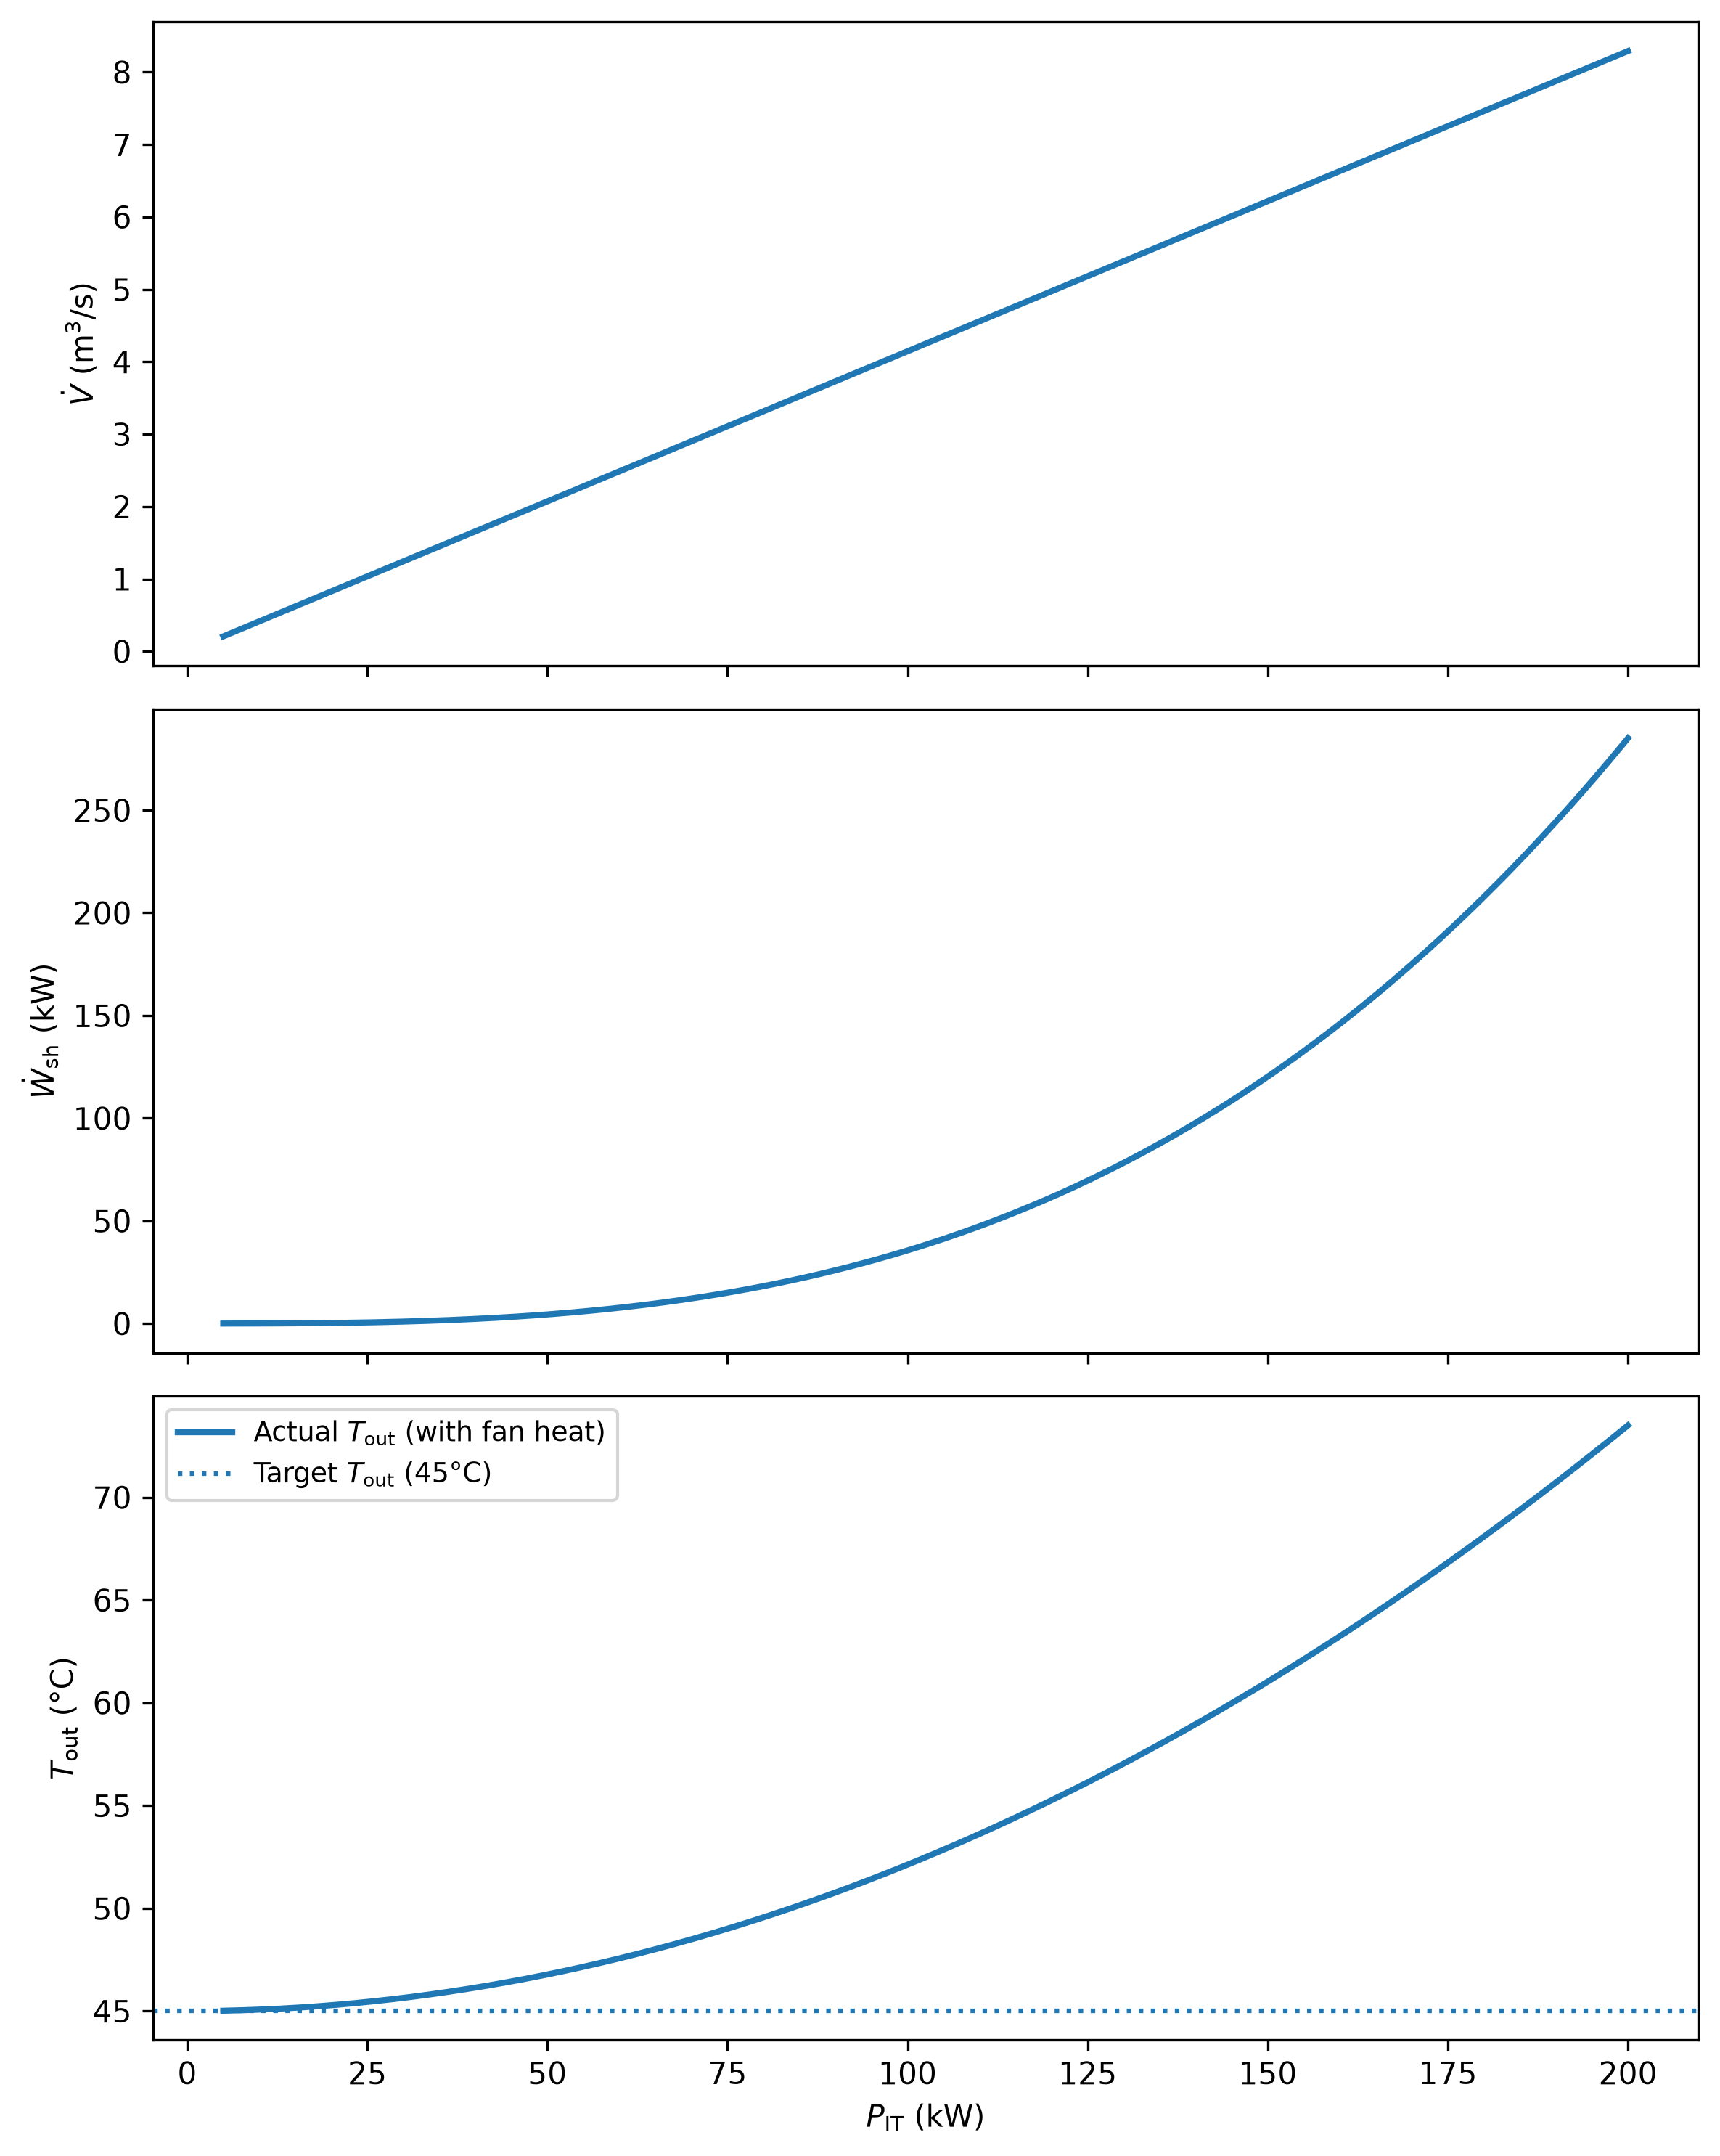

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs
T_in = 25.0              # Fixed inlet air temperature [°C]
delta_T_desired = 20.0   # Desired temperature rise [°C] (Target T_out = 45°C)
rho = 1.2                # Fluid density of air [kg/m^3]
cp = 1005                # Specific heat capacity of air [J/(kg·K)]

eta_fan = 0.50           # Combined fan efficiency 
k_sys = 250.0            # Rack flow resistance coefficient [Pa / (m^3/s)^2]

P_IT_kW = np.linspace(5.0, 200.0, 300)
P_IT = P_IT_kW * 1e3     # Convert to Watts [W]

# Calculations
# m_dot = P_IT / (c_p * ΔT_desired)
m_dot = P_IT / (cp * delta_T_desired)  # Mass flow rate [kg/s]
V_dot = m_dot / rho                    # Volumetric flow rate [m^3/s]
# Flow resistance: Δp = k_sys * V_dot^2
# Fan Power Input: W_fan = (V_dot * Δp) / η_fan = (k_sys * V_dot^3) / η_fan
delta_p = k_sys * (V_dot**2)           # Pressure rise across rack [Pa]
W_fan = (V_dot * delta_p) / eta_fan    # Fan power input [W]
W_fan_kW = W_fan / 1e3                # Convert to [kW]
# Q_total = P_IT + W_fan = m_dot * c_p * (T_out_actual - T_in)
# T_out_actual = T_in + (P_IT + W_fan) / (m_dot * c_p)
delta_T_actual = (P_IT + W_fan) / (m_dot * cp)
T_out_actual = T_in + delta_T_actual  # Actual outlet temperature [°C]

# Plots
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True, dpi=300)

# Air Volumetric Flow Rate vs. Rack IT Power
axes[0].plot(P_IT_kW, V_dot, linewidth=2)
axes[0].set_ylabel(r'$\dot{V}$ ($\mathrm{m^3/s}$)', fontsize=14)
#axes[0].set_title('Air Volumetric Flow Rate vs. Rack IT Power', fontsize=11, pad=8)
#axes[0].grid(True, linestyle='--', alpha=0.6)

# Fan Power Input vs. Rack IT Power
axes[1].plot(P_IT_kW, W_fan_kW, linewidth=2)
axes[1].set_ylabel(r'$\dot{W}_{\mathrm{sh}}$ ($\mathrm{kW}$)', fontsize=14)
#axes[1].set_title('Fan Power Input vs. Rack IT Power', fontsize=11, pad=8)
#axes[1].grid(True, linestyle='--', alpha=0.6)

# Actual Air Outlet Temperature vs. Rack IT Power
axes[2].plot(P_IT_kW, T_out_actual, linewidth=2, label='Actual $T_{\mathrm{out}}$ (with fan heat)')
axes[2].axhline(T_in + delta_T_desired, linestyle=':', linewidth=1.5, label=f'Target $T_{{\mathrm{{out}}}}$ ({T_in + delta_T_desired:.0f}°C)')
axes[2].set_xlabel('$P_{\mathrm{IT}}$ ($\mathrm{kW}$)', fontsize=14)
axes[2].set_ylabel(r'$T_{\mathrm{out}}$ (°C)', fontsize=14)
#axes[2].set_title('Air Outlet Temperature vs. Rack IT Power', fontsize=11, pad=8)
#axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig('../lectures/figures/rack_cooling_plots.pdf')
plt.show()

# Fluid Dynamics and Thermal Management: Theoretical Foundations

## 1. The Betz Limit (Actuator Disk Theory)
The Betz limit defines the maximum theoretical efficiency of a device (like a wind turbine) extracting kinetic energy from a fluid. While fans *add* energy, the underlying physics is governed by the same **Actuator Disk Theory**.

### 1.1 Assumptions
*   The fluid is incompressible and the flow is steady.
*   The actuator disk is an idealized surface that imparts pressure/energy without friction.
*   The flow is one-dimensional.

### 1.2 Derivation
Let:
*   $v_1$ = Upstream velocity
*   $v_2$ = Downstream velocity
*   $v_d$ = Velocity at the disk
*   $\rho$ = Fluid density
*   $A$ = Area of the disk

**1. Conservation of Momentum:**
The thrust $T$ exerted by the disk is equal to the change in momentum flux:
$$T = \dot{m}(v_1 - v_2)$$
where the mass flow rate $\dot{m} = \rho A v_d$. 

According to actuator disk theory, the velocity at the disk is the average of the upstream and downstream velocities:
$$v_d = \frac{v_1 + v_2}{2}$$

**2. The Induction Factor ($a$):**
We define the induction factor $a$ such that:
$$v_d = v_1(1 - a)$$
$$v_2 = v_1(1 - 2a)$$

**3. Power Extraction:**
The power $P$ extracted from the fluid is the product of thrust and the velocity at the disk:
$$P = T \cdot v_d = [\rho A v_d (v_1 - v_2)] \cdot v_d$$
Substitute $v_d$ and $v_2$ in terms of $a$:
$$P = \rho A [v_1(1-a)]^2 [v_1 - v_1(1-2a)]$$
$$P = \rho A v_1^3 (1-a)^2 (2a) = 2a(1-a)^2 \rho A v_1^3$$

**4. Maximizing the Power Coefficient ($C_p$):**
The power available in the wind is $P_{wind} = \frac{1}{2} \rho A v_1^3$. The coefficient $C_p$ is:
$$C_p = \frac{P}{P_{wind}} = \frac{2a(1-a)^2 \rho A v_1^3}{\frac{1}{2} \rho A v_1^3} = 4a(1-a)^2$$

To find the maximum, we take the derivative with respect to $a$ and set it to zero:
$$\frac{dC_p}{da} = 4[(1-a)^2 + a \cdot 2(1-a)(-1)] = 4(1-a)(1-3a) = 0$$

The non-trivial solution is **$a = 1/3$**.

**5. The Result:**
Substituting $a = 1/3$ back into the $C_p$ equation:
$$C_p = 4\left(\frac{1}{3}\right)\left(1 - \frac{1}{3}\right)^2 = 4\left(\frac{1}{3}\right)\left(\frac{4}{9}\right) = \frac{16}{27} \approx 0.593$$

**Conclusion:** The maximum theoretical efficiency for energy conversion is **59.3%**.

---

## 2. The Fan Laws (Affinity Laws)
For a centrifugal or axial fan operating within its design envelope, the performance characteristics scale predictably with the rotational speed ($n$).

| Parameter | Scaling Law | Relationship |
| :--- | :--- | :--- |
| **Flow Rate ($Q$)** | $Q \propto n$ | $Q_2 = Q_1 (\frac{n_2}{n_1})$ |
| **Pressure ($\Delta P$)** | $\Delta P \propto n^2$ | $\Delta P_2 = \Delta P_1 (\frac{n_2}{n_1})^2$ |
| **Power ($W$)** | $W \propto n^3$ | $W_2 = W_1 (\frac{n_2}{n_1})^3$ |

---

## 3. The Critical Cooling Speed
In thermal management, increasing fan speed is intended to increase convective heat removal. However, there is a physical limit where increasing the fan speed actually **increases** the temperature of the system.

### 3.1 The Physics of the Trade-off
1.  **Heat Removal ($q_{conv}$):** As fan speed $n$ increases, the Reynolds number increases, enhancing the convective heat transfer coefficient ($h$).
    $$q_{conv} \propto n^\alpha \quad \text{where } 0.5 < \alpha < 0.8$$
2.  **Heat Generation ($q_{gen}$):** The electrical power consumed by the fan is converted almost entirely into heat within the system.
    $$q_{gen} \propto n^3$$

### 3.2 Finding the Critical Point
The net cooling effectiveness $\dot{Q}_{net}$ is defined as:
$$\dot{Q}_{net} = k_1 n^\alpha - k_2 n^3$$

To find the **Critical Speed ($n_{crit}$)**, where the marginal cooling benefit becomes zero:
$$\frac{d\dot{Q}_{net}}{dn} = \alpha k_1 n^{\alpha-1} - 3 k_2 n^2 = 0$$
$$\alpha k_1 n^{\alpha-1} = 3 k_2 n^2$$
$$n^{3-\alpha} = \frac{\alpha k_1}{3 k_2}$$
$$n_{crit} = \left( \frac{\alpha k_1}{3 k_2} \right)^{\frac{1}{3-\alpha}}$$

**Engineering Implication:** Beyond $n_{crit}$, the fan is "fighting itself." The heat added by the fan's own motor power exceeds the additional heat removed by the increased airflow, leading to a thermal runaway effect or a higher steady-state temperature.


## Comparative Cooling Efficiency (Water vs. Air)

While many attribute water's cooling superiority simply to its "heat capacity," a fundamental explanation exists within **boundary layer theory**—specifically regarding the relationship between momentum and thermal diffusion.

### 1. The Role of the Prandtl Number ($Pr$)
The primary driver is the **Prandtl Number**, defined as the ratio of momentum diffusivity to thermal diffusivity:
$$Pr = \frac{\nu}{\alpha}$$

*   **Air ($Pr \approx 0.7$):** Since $Pr$ is close to $1$, the momentum boundary layer ($\delta_L$) and the thermal boundary layer ($\delta_T$) are roughly the same thickness ($\delta_T \approx \delta_L$). Heat and momentum diffuse through the fluid at similar rates.
*   **Water ($Pr \approx 7.0$):** Because $Pr \gg 1$, momentum diffuses much faster than heat. This causes the thermal boundary layer to be significantly **thinner** than the momentum boundary layer ($\delta_T < \delta_L$).

### 2. The Temperature Gradient at the Wall ($\theta'(0)$)
As derived in the Blasius extension, the rate of heat transfer is governed by the dimensionless temperature gradient at the wall, $\theta'(0)$. 

In water, the high Prandtl number "compresses" the thermal boundary layer closer to the solid surface. A thinner thermal boundary layer necessitates a much **steeper temperature gradient** to transport the same amount of energy. Mathematically, as $Pr$ increases, the value of the wall gradient $\theta'(0)$ increases:
$$\text{Higher } Pr \implies \text{Thinner } \delta_T \implies \text{Steeper } \theta'(0)$$

### 3. Impact on the Nusselt Number ($Nu_x$)
The convective heat transfer coefficient ($h$) is directly proportional to the **Nusselt Number**, which is linked to the wall gradient by:
$$\boxed{Nu_x = \theta'(0) \sqrt{Re_x}}$$

Because water's $Pr$ results in a much higher $\theta'(0)$ compared to air, water achieves a significantly higher Nusselt number for a given Reynolds number. This means that even if we matched the flow velocities (Reynolds numbers) of air and water, water would still transfer heat more effectively because its thermal boundary layer is more "aggressive" at the wall interface.

### Summary Comparison
| Property | Air ($Pr \approx 0.7$) | Water ($Pr \approx 7.0$) | Result for Water |
| :--- | :--- | :--- | :--- |
| **Boundary Layer Ratio** | $\delta_T \approx \delta_L$ | $\delta_T < \delta_L$ | Thinner thermal layer |
| **Wall Gradient $\theta'(0)$** | Lower | Higher | Steeper heat flux |
| **Heat Transfer ($Nu_x$)** | Lower | Higher | **Superior Cooling** |